## Diagnostyka danych

In [2]:
# ============================================
#                   Importy 
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# ============================================
#               Wczytanie danych 
# ============================================

df = pd.read_csv("World Energy Consumption.csv")

# ============================================
#               Diagnostyka danych
# ============================================

df.head()

#df.describe()  # Statystyki opisowe dla kolumn numerycznych (min, max, średnia, kwartyle)


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [3]:
df.info()
print("Duplikaty:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Columns: 129 entries, country to wind_share_energy
dtypes: float64(126), int64(1), str(2)
memory usage: 21.9 MB
Duplikaty: 0


In [4]:
# Typy danych
df.dtypes




country                       str
year                        int64
iso_code                      str
population                float64
gdp                       float64
                           ...   
wind_elec_per_capita      float64
wind_electricity          float64
wind_energy_per_capita    float64
wind_share_elec           float64
wind_share_energy         float64
Length: 129, dtype: object

In [5]:
# ============================================
#         Sprawdzenie braków danych
# ============================================

# Zliczenia brakujących wartości (NaN/null) w każdej kolumnie i wyświetlenia ich w kolejności od tej, która ma tych braków najwięcej.
df.isna().sum().sort_values(ascending=False) 



biofuel_cons_change_pct    20265
solar_cons_change_pct      19888
biofuel_cons_per_capita    19710
wind_cons_change_pct       19599
nuclear_cons_change_pct    19545
                           ...  
oil_prod_change_twh         4864
oil_production              4607
population                  3889
country                        0
year                           0
Length: 129, dtype: int64

In [6]:
# Łączna liczba braków danych w danym roku.

missing_by_year = df.groupby('year').apply(lambda x: x.isna().sum().sum())
missing_by_year

year
1900    14224
1901    13871
1902    13869
1903    13868
1904    13866
        ...  
2018    17382
2019    17700
2020    17586
2021    17465
2022     6658
Length: 123, dtype: int64

In [7]:
# Sprawdzenie braków dla krajów

df.groupby('country').apply(lambda x: x.isna().mean()).sort_values('primary_energy_consumption')

,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
country,,,,,,,,,,,,,,,,,,,,,
Asia & Oceania (EIA),0.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Asia Pacific (EI),0.0,1.0,1.0,1.000000,0.655172,0.017241,1.0,0.0,1.000000,1.000000,...,0.344828,0.000000,0.448276,0.017241,0.000000,1.000000,0.000000,1.000000,0.344828,0.000000
Australia and New Zealand (EIA),0.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Azerbaijan,0.0,0.0,0.0,0.105263,1.000000,1.000000,1.0,1.0,0.421053,0.421053,...,0.131579,0.131579,0.710526,0.157895,0.131579,0.131579,0.131579,0.131579,0.131579,0.131579
Bahamas,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.0,1.0,0.476190,0.476190,...,0.476190,1.000000,1.000000,1.000000,1.000000,0.476190,0.476190,1.000000,0.476190,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G20 (Ember),0.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,0.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000
Europe (Shift),0.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Asia and Oceania (Shift),0.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Wizualizacja braków

Text(0.5, 1.0, 'Braki współistniejące')

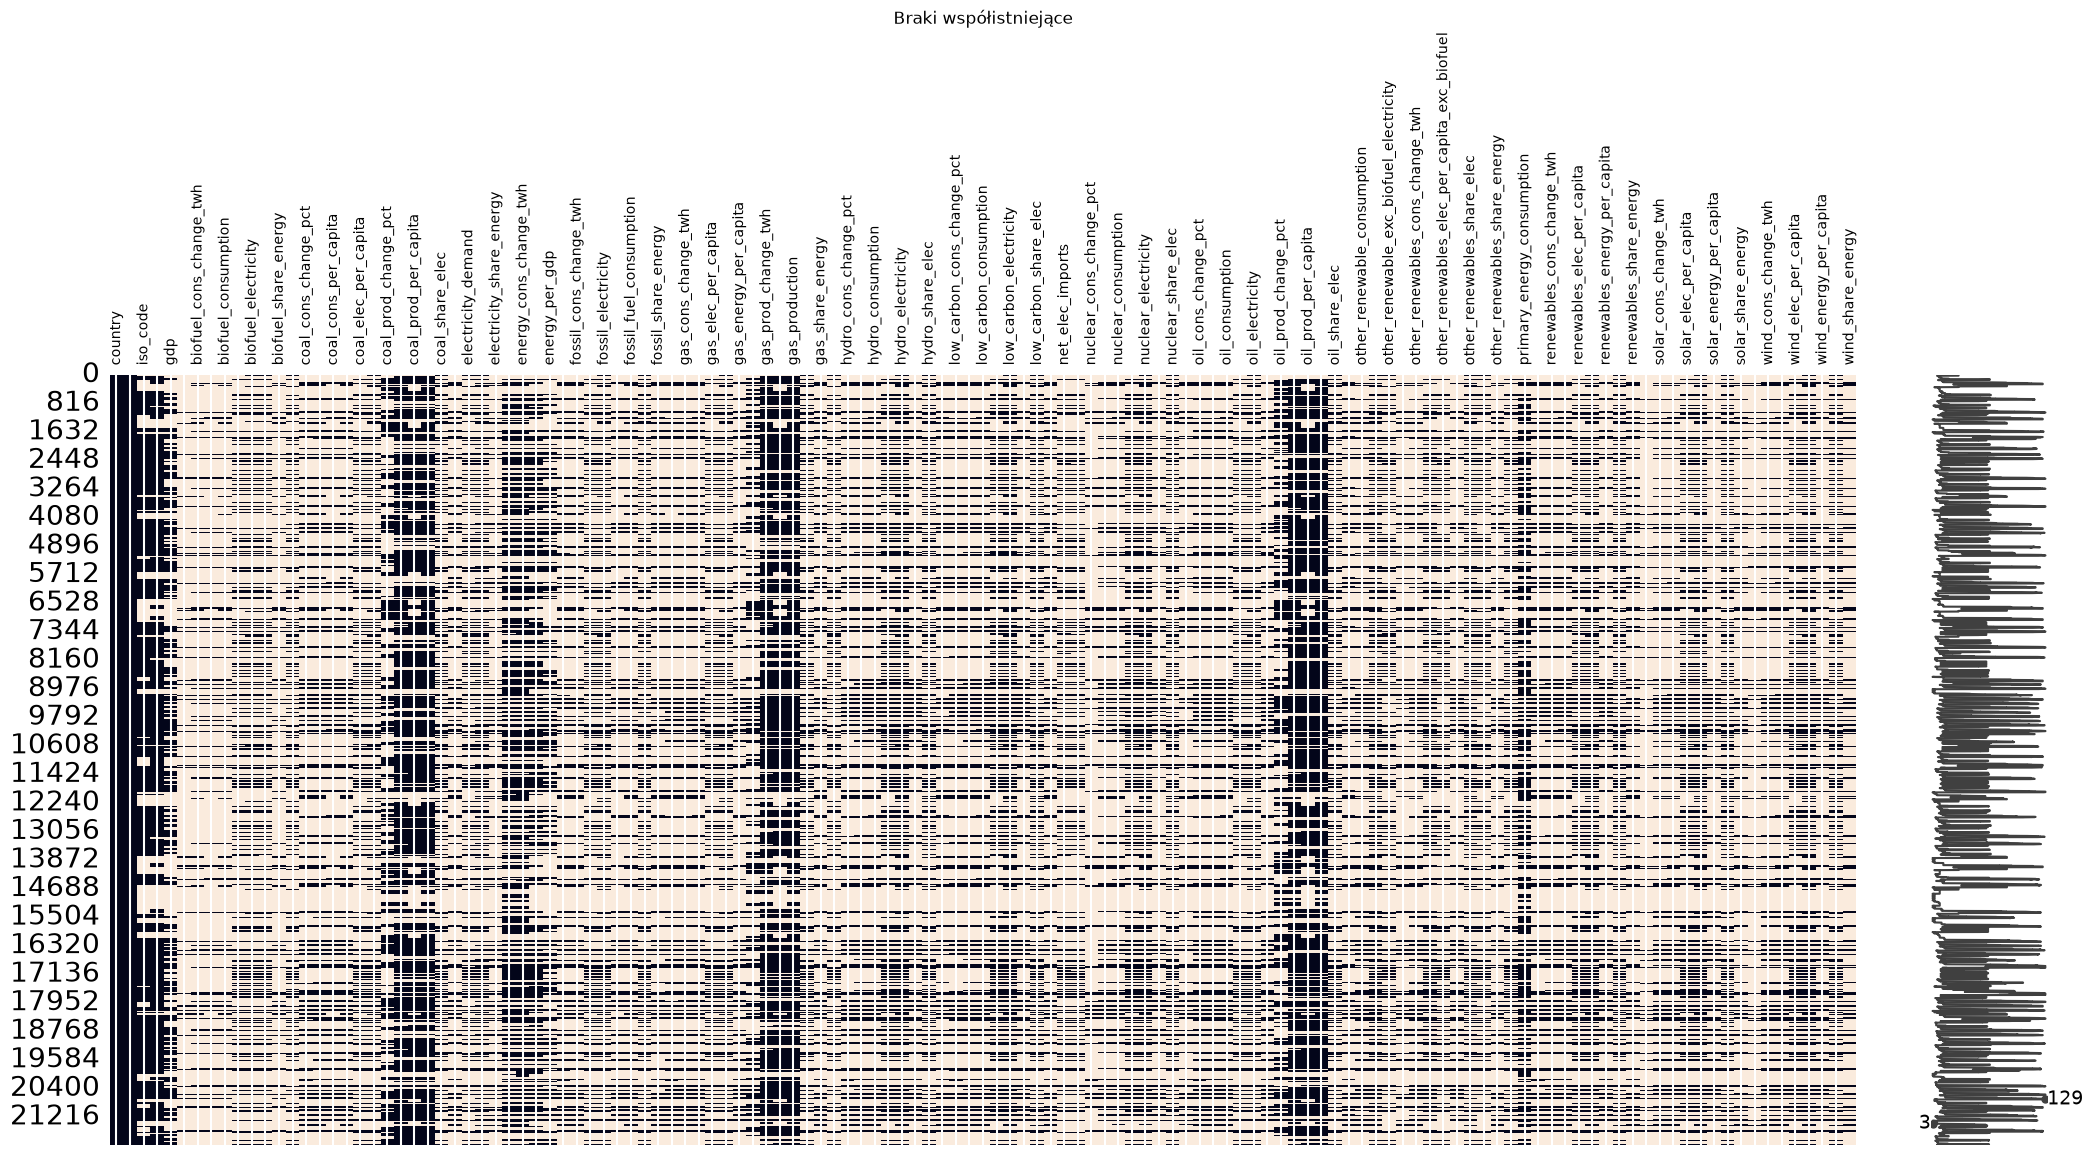

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

"""
matrix – czy braki występują w blokach (np. starsze lata),
heatmap – czy braki współwystępują (np. brak solar → brak wind),
Heatmapa braków danych przedstawia zmienne na osi X oraz obserwacje (kraj–rok) na osi Y.
Jasne pola oznaczają wartości brakujące, a ciemne pola wartości dostępne. 
"""
msno.matrix(df);
plt.title('Braki')

sns.heatmap(df.isna(), cbar=False)  
plt.title('Braki współistniejące')



<Axes: >

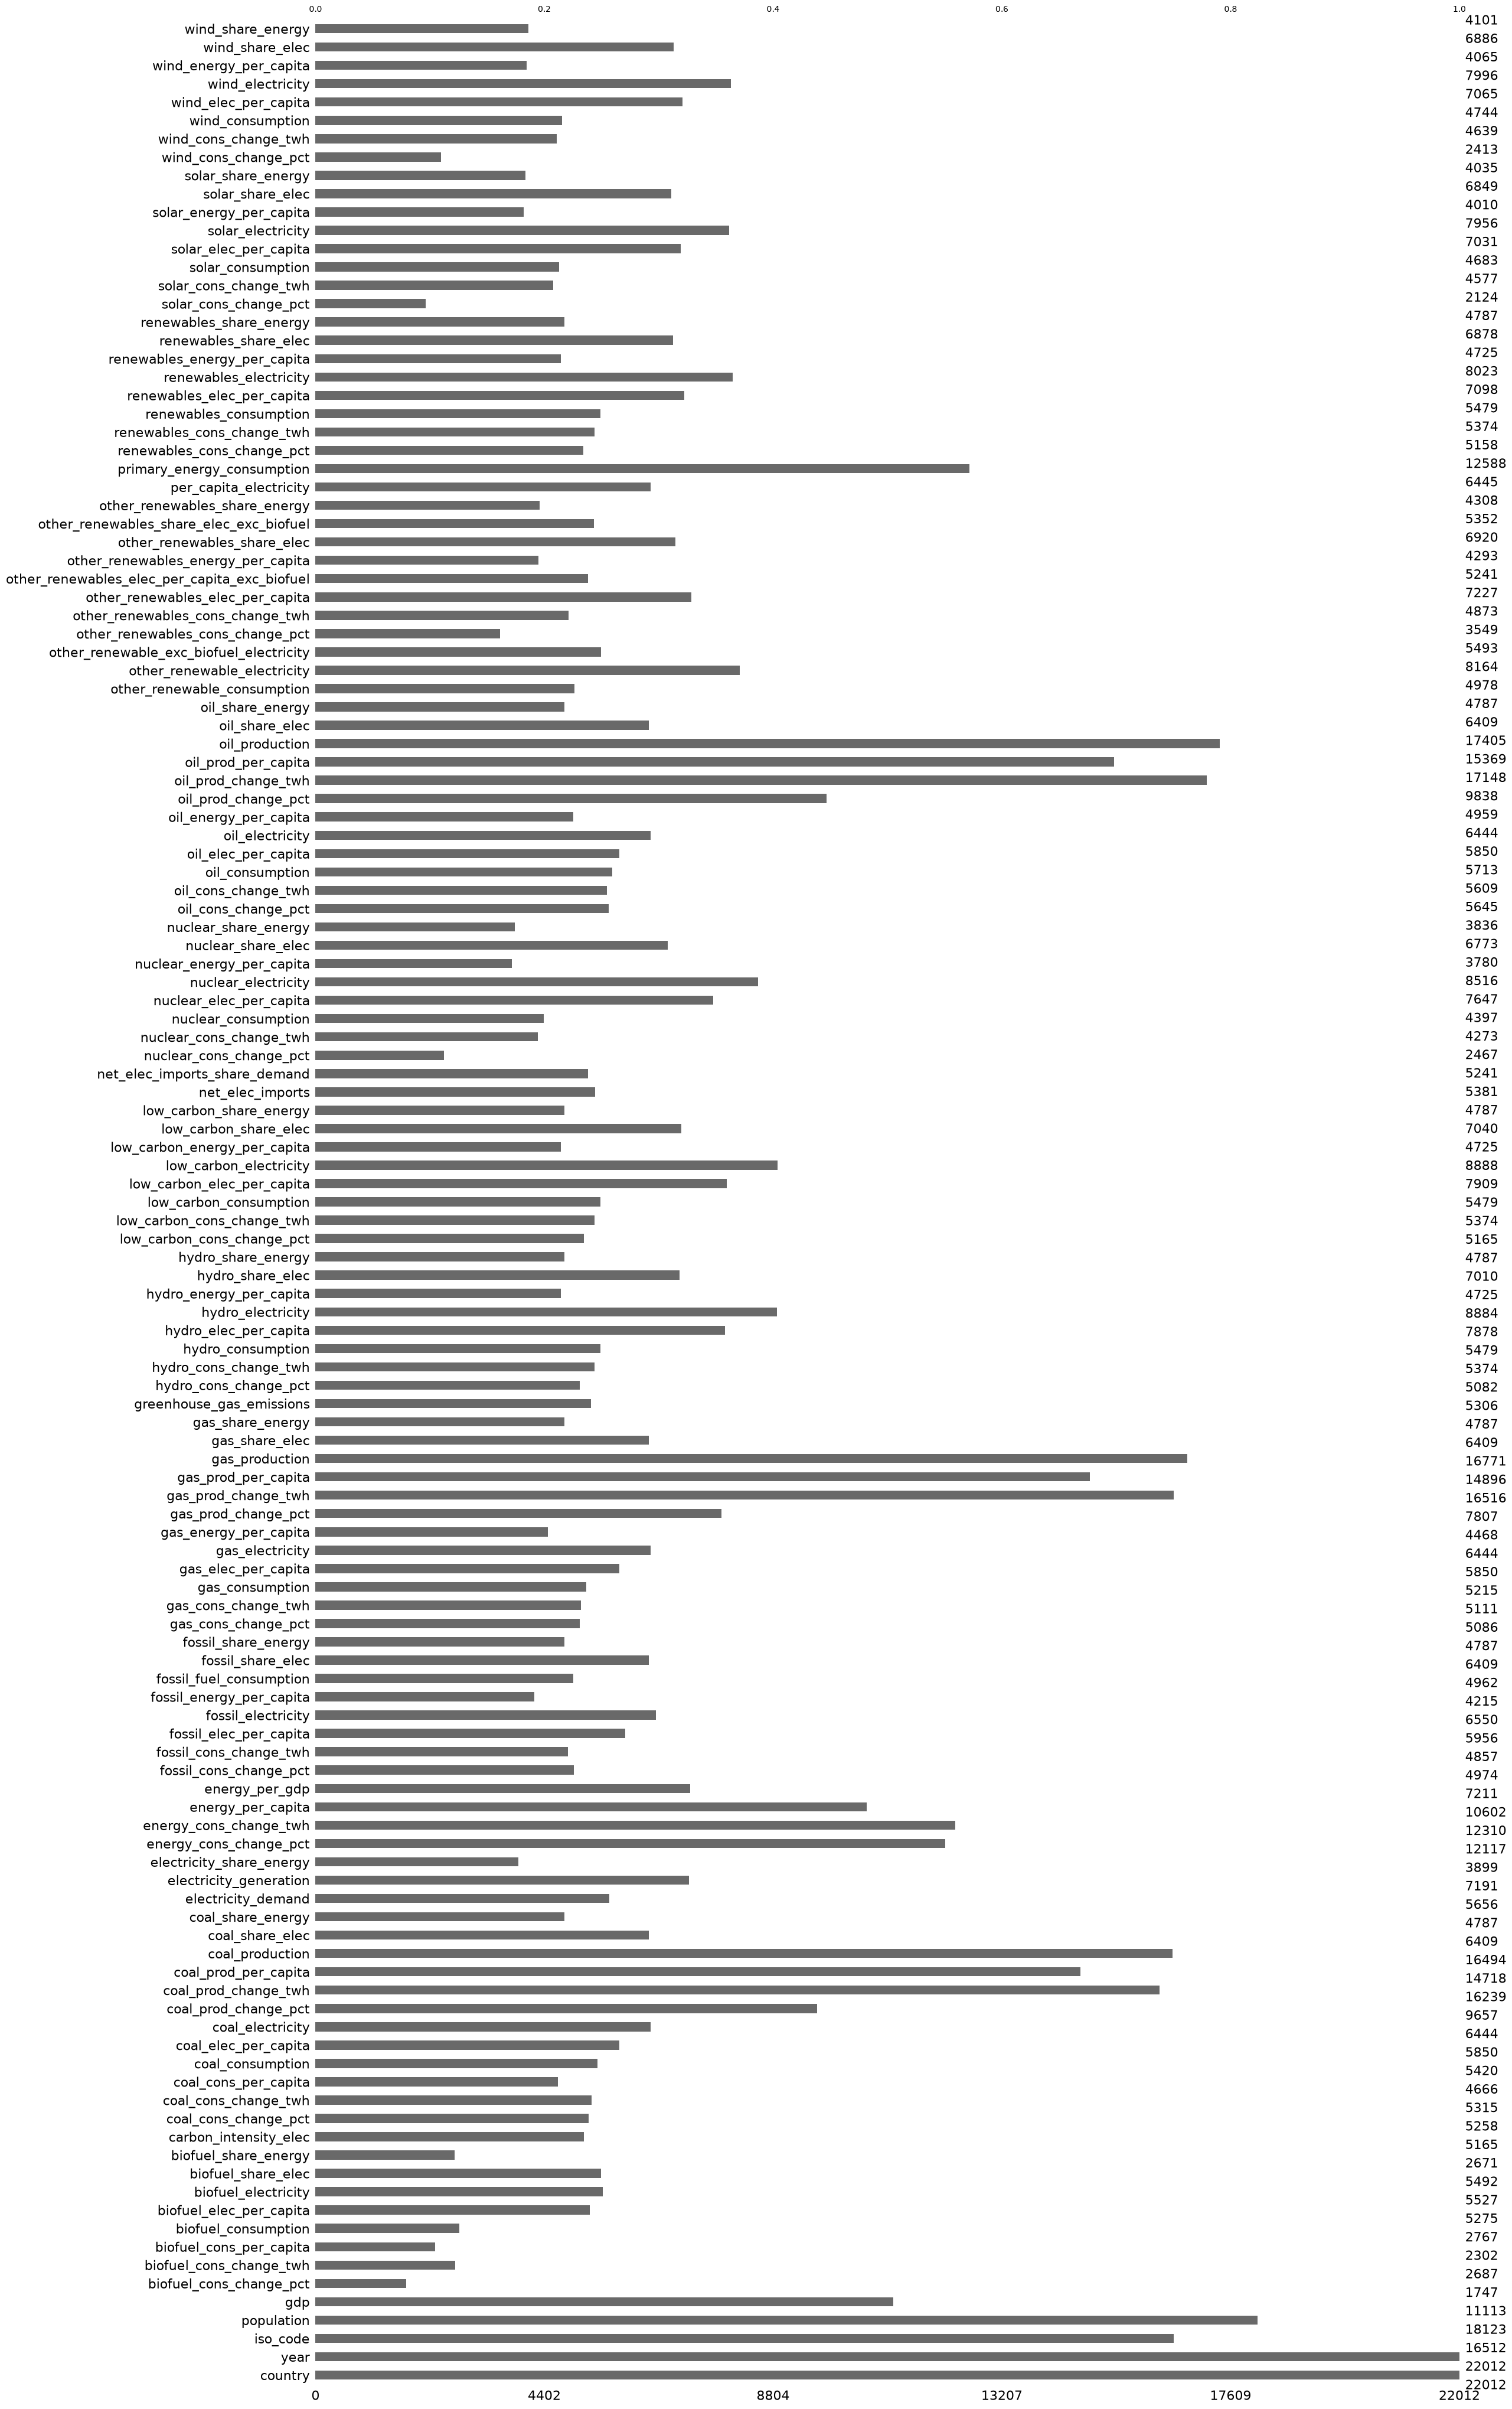

In [30]:
# bar – ile braków ma każda kolumna.
msno.bar(df)

Text(0.5, 1.0, 'Procent braków danych dla każdej zmiennej w czasie')

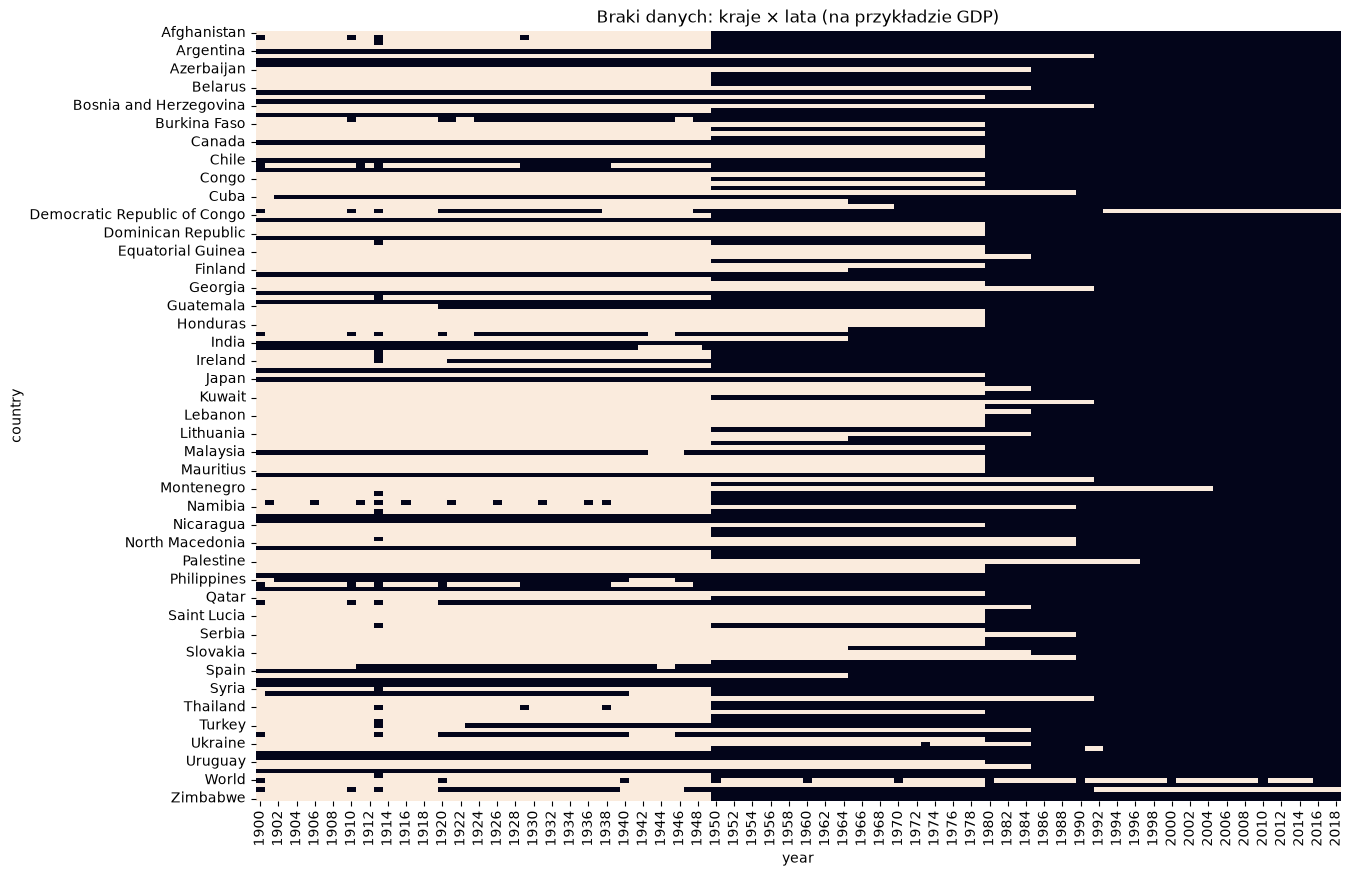

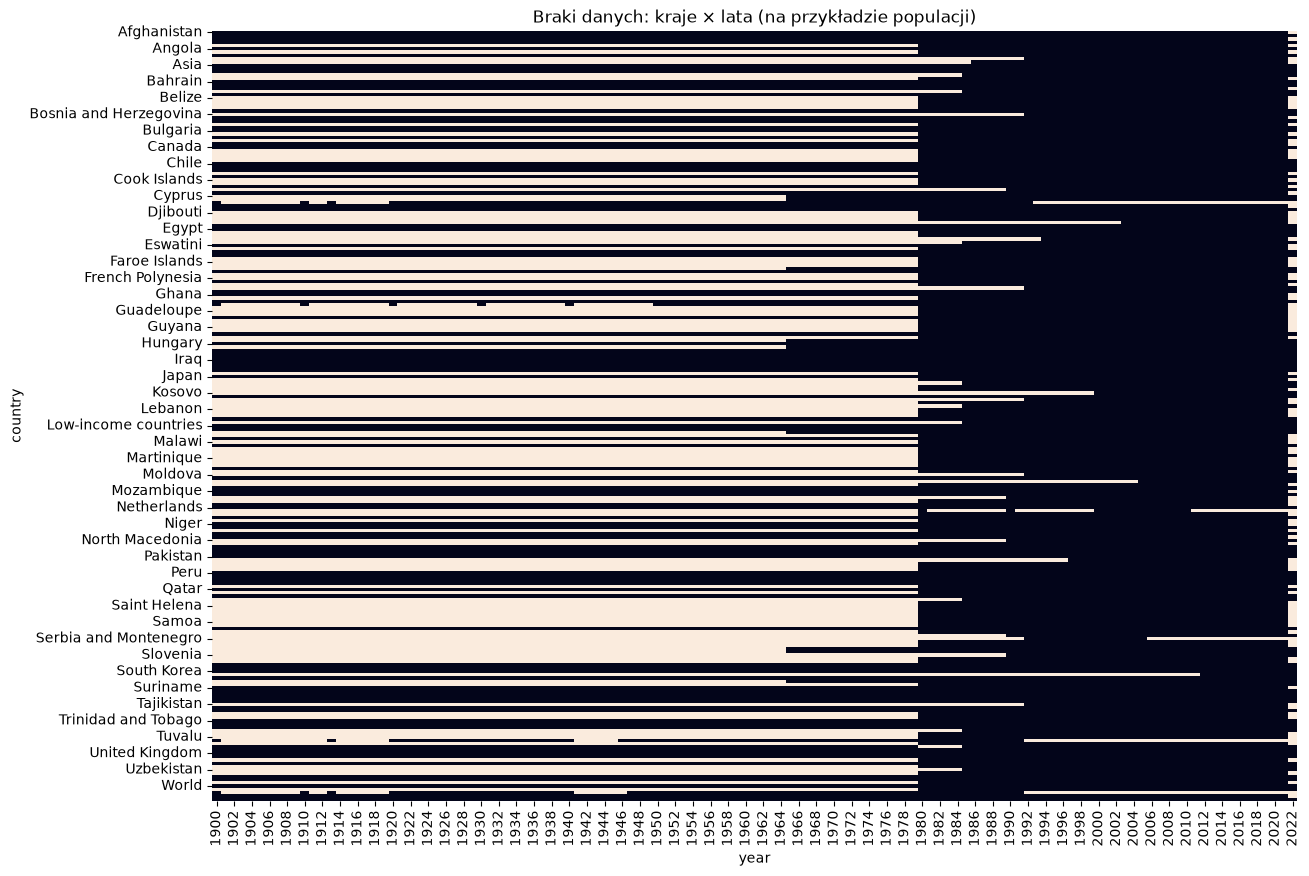

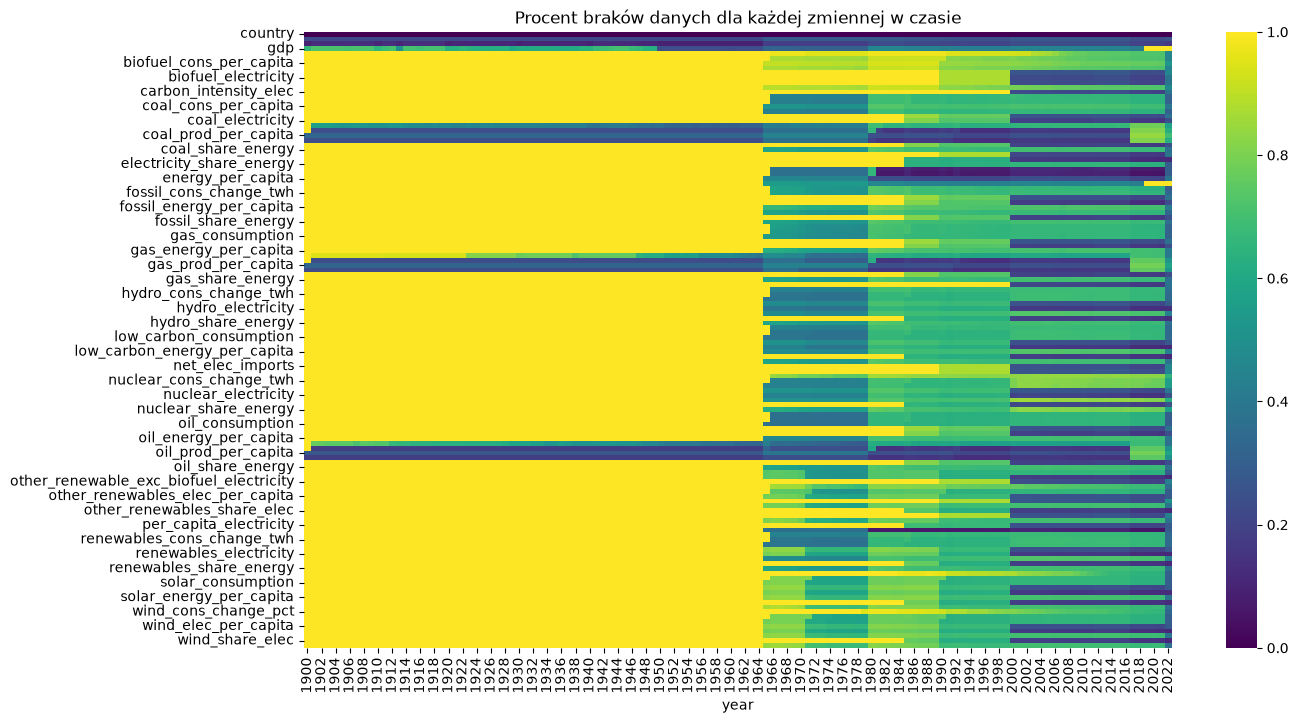

In [31]:
plt.figure(figsize=(14,10))
sns.heatmap(df.pivot_table(index='country', columns='year', values='gdp').isna(), 
            cbar=False)
plt.title('Braki danych: kraje × lata (na przykładzie GDP)')



plt.figure(figsize=(14,10))
sns.heatmap(df.pivot_table(index='country', columns='year', values='population').isna(), 
            cbar=False)
plt.title('Braki danych: kraje × lata (na przykładzie populacji)')



missing_by_year_var = df.groupby('year').apply(lambda x: x.isna().mean())
plt.figure(figsize=(14,8))
sns.heatmap(missing_by_year_var.T, cmap='viridis')
plt.title('Procent braków danych dla każdej zmiennej w czasie')

## Czyszczenie danych
* usunięcie regonów - nieprzydatne wiersze,
* usuniecie zmiennych o zbyt dużej liczbie braków (przyjete powyzej 60%),
* zmiejszenie zakresu lat ( od 2000 roku).

W ramach czyszczenia danych usunięto wiersze odpowiadające regionom agregowanym (np. „World”, „Europe”, „OECD”), ponieważ nie reprezentują pojedynczych krajów i mają odmienne zakresy danych. Następnie usunięto zmienne zawierające ponad 60% braków, gdyż nie nadają się do rzetelnej analizy. Ograniczono również zakres lat do okresu od 2000 roku, ponieważ starsze dane charakteryzują się dużą liczbą braków oraz mniejszą spójnością. Dzięki tym krokom uzyskano bardziej kompletny, porównywalny i wiarygodny zbiór danych do dalszej analizy eksploracyjnej.

In [35]:
# ============================================
#         Usuwanie zbędnych danych
# ============================================


# Lista regionów do usunięcia

regions = ['World', 'Africa', 'Asia', 'Europe', 'European Union', 'North America',
           'South America', 'Oceania', 'High-income countries', 'Low-income countries',
           'Upper-middle-income countries', 'Lower-middle-income countries', 'OECD']

df = df[~df['country'].isin(regions)]

Usunięto wiersze odpowiadające regionom agregowanym, ponieważ nie reprezentują pojedynczych krajów i mają odmienne zakresy danych. Pozostawiono wyłącznie dane krajowe, co zwiększa spójność analizy.

In [34]:
# Usunięcie zmiennych z >60% braków
threshold = 0.6
df = df.loc[:, df.isna().mean() < threshold]

Usunięto zmienne, które miały ponad 60% braków. Pozwoliło to zachować tylko te cechy, które są wystarczająco kompletne, aby przeprowadzić rzetelną analizę.

# Imputacja braków

In [36]:
# wybór kolumn numerycznych
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# interpolacja po krajach z zachowaniem indeksu
df[num_cols] = df.groupby('country')[num_cols].transform(lambda x: x.interpolate())

# Filtrowanie danych lata po 2000 roku

In [37]:
# filtrowanie danych 
df = df[df['year'] >= 2000]

Ograniczono analizę do lat od 2000 roku, ponieważ starsze dane charakteryzują się dużą liczbą braków oraz mniejszą spójnością. Dzięki temu uzyskano bardziej kompletny i aktualny zbiór danych.